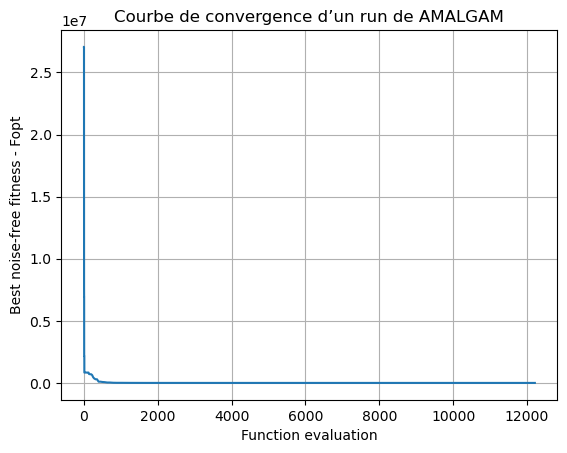

In [5]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

data = []
start = False

for line in lines:
    line = line.strip()
    
    # Début du premier run
    if line.startswith("%") and not start:
        start = True
        continue
    
    # Stop au deuxième %
    if line.startswith("%") and start:
        break
    
    # Ajouter les lignes du run
    if start and line:
        values = line.split()
        data.append(values)

# Extraire colonnes
x = [float(row[0]) for row in data]  # evaluation
y = [float(row[2]) for row in data]  # best noise-free fitness

# Graph
plt.plot(x, y)

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbe de convergence d’un run de AMALGAM")
plt.grid()
plt.show()

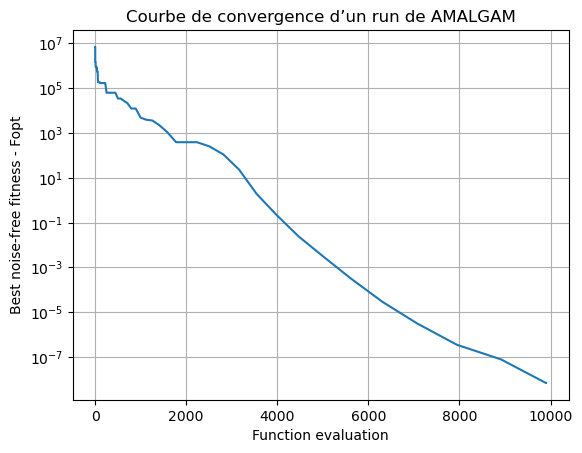

In [4]:
plt.plot(x, y)
plt.yscale("log")
plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbe de convergence d’un run de AMALGAM")
plt.grid()
plt.show()

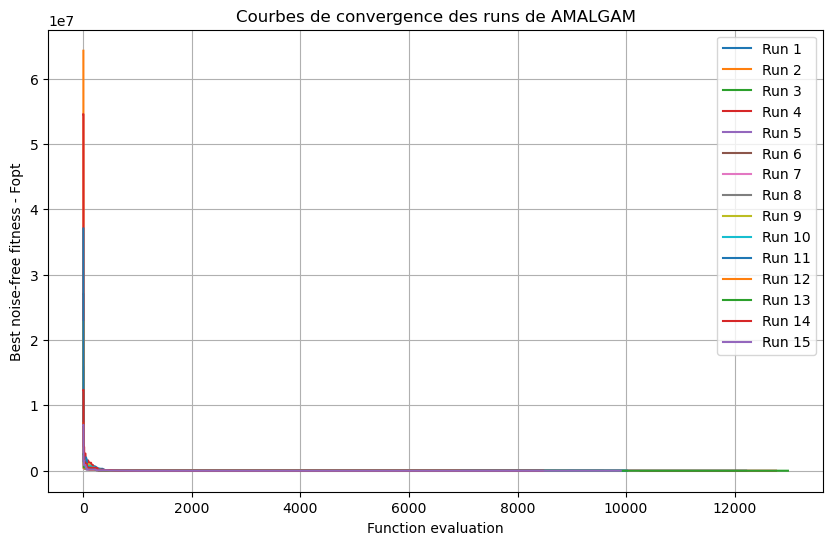

In [2]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    # Si on trouve %, on commence un nouveau run
    if line.startswith("%"):
        if current_run:          # sauvegarder le run précédent
            runs.append(current_run)
            current_run = []
    else:
        if line:                 # ignorer les lignes vides
            current_run.append(line.split())

# Ajouter le dernier run
if current_run:
    runs.append(current_run)

# Tracer tous les runs
plt.figure(figsize=(10, 6))

for i, run in enumerate(runs):
    x = [float(row[0]) for row in run]
    y = [float(row[2]) for row in run]
    plt.plot(x, y, label=f"Run {i+1}")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes de convergence des runs de AMALGAM")
plt.legend()
plt.grid()
plt.show()

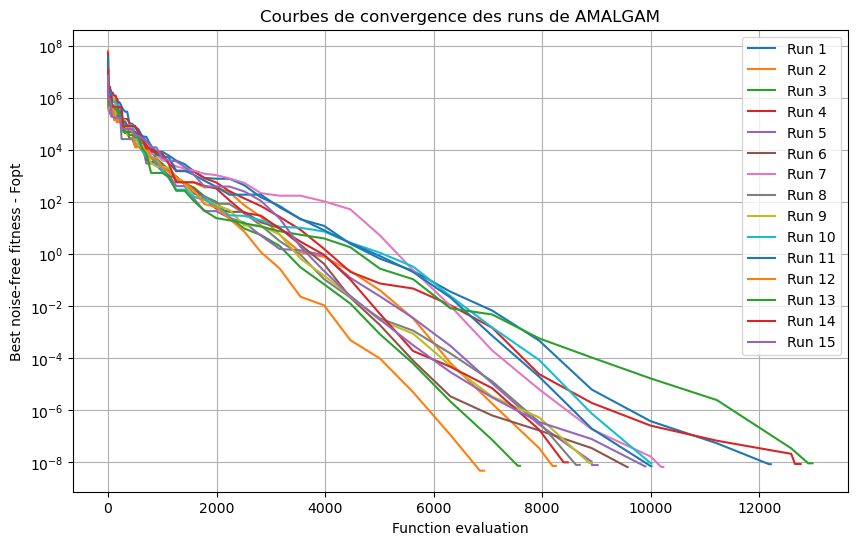

In [22]:
import matplotlib.pyplot as plt

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    # Si on trouve %, on commence un nouveau run
    if line.startswith("%"):
        if current_run:          # sauvegarder le run précédent
            runs.append(current_run)
            current_run = []
    else:
        if line:                 # ignorer les lignes vides
            current_run.append(line.split())

# Ajouter le dernier run
if current_run:
    runs.append(current_run)

# Tracer tous les runs
plt.figure(figsize=(10, 6))

for i, run in enumerate(runs):
    x = [float(row[0]) for row in run]
    y = [float(row[2]) for row in run]
    plt.plot(x, y, label=f"Run {i+1}")

plt.yscale("log")
plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes de convergence des runs de AMALGAM")
plt.legend()
plt.grid()
plt.show()



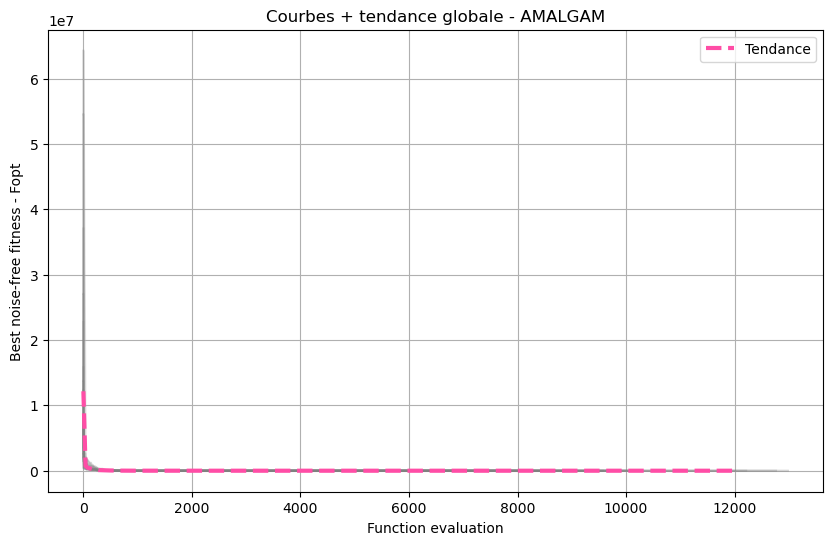

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    if line.startswith("%"):
        if current_run:
            runs.append(current_run)
            current_run = []
    else:
        if line:
            current_run.append(line.split())

if current_run:
    runs.append(current_run)

# 🔥 axe commun
x_common = np.linspace(1, 12000, 300)

ys = []

plt.figure(figsize=(10, 6))

# --- runs + interpolation ---
for run in runs:
    x = np.array([float(row[0]) for row in run])
    y = np.array([float(row[2]) for row in run])

    # tracer les runs (gris léger)
    plt.plot(x, y, color="gray", alpha=0.3)

    # interpolation
    y_interp = np.interp(x_common, x, y)

    # éviter log(0)
    y_interp[y_interp <= 0] = 1e-12

    ys.append(y_interp)

ys = np.array(ys)

# 🔥 moyenne en log (IMPORTANT)
y_mean = np.exp(np.mean(np.log(ys), axis=0))

# bande min/max
y_min = np.min(ys, axis=0)
y_max = np.max(ys, axis=0)

# --- bande ---
plt.fill_between(x_common, y_min, y_max, color="gray", alpha=0.2)

# --- tendance ---
plt.plot(
    x_common,
    y_mean,
    color="#ff4da6",
    linestyle="--",
    linewidth=3,
    label="Tendance"
)


plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Courbes + tendance globale - AMALGAM")

plt.legend()
plt.grid()
plt.show()

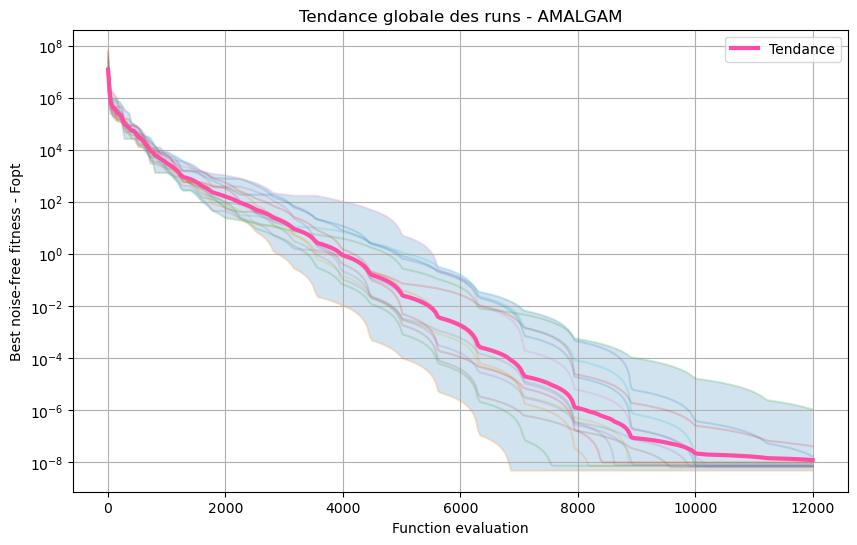

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lire le fichier
with open("bbobexp_f10_DIM10.tdat", "r") as f:
    lines = f.readlines()

runs = []
current_run = []

for line in lines:
    line = line.strip()

    if line.startswith("%"):
        if current_run:
            runs.append(current_run)
            current_run = []
    else:
        if line:
            current_run.append(line.split())

if current_run:
    runs.append(current_run)

# axe commun
x_common = np.linspace(1, 12000, 300)

ys = []

for run in runs:
    x = np.array([float(row[0]) for row in run])
    y = np.array([float(row[2]) for row in run])

    # interpolation
    y_interp = np.interp(x_common, x, y)

    # éviter log(0)
    y_interp[y_interp <= 0] = 1e-12

    ys.append(y_interp)

ys = np.array(ys)

#  MOYENNE EN LOG 
y_mean = np.exp(np.mean(np.log(ys), axis=0))

# bande min/max
y_min = np.min(ys, axis=0)
y_max = np.max(ys, axis=0)


plt.figure(figsize=(10,6))

# runs (transparent)
for y in ys:
    plt.plot(x_common, y, alpha=0.2)

# bande
plt.fill_between(x_common, y_min, y_max, alpha=0.2)

# moyenne 
plt.plot(x_common, y_mean, color="#ff4da6", linewidth=3, label="Tendance")

plt.yscale("log")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Tendance globale des runs - AMALGAM")

plt.legend()
plt.grid()
plt.show()

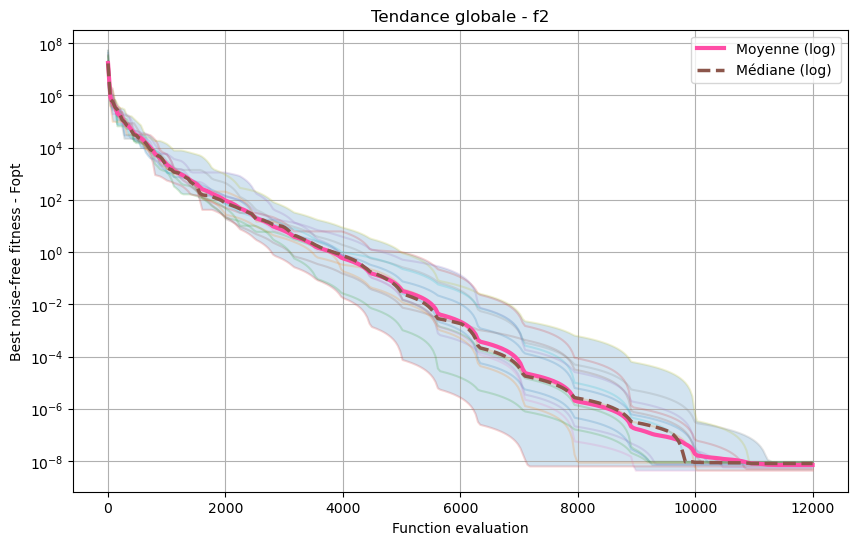

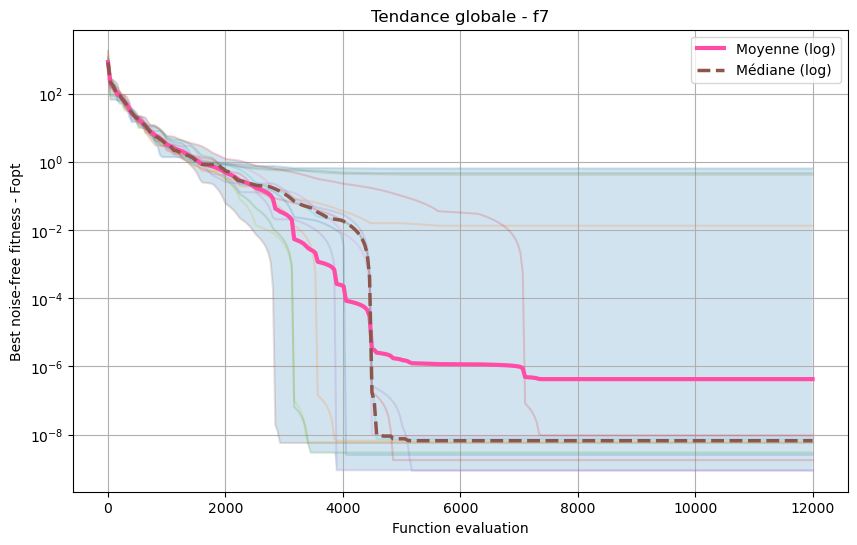

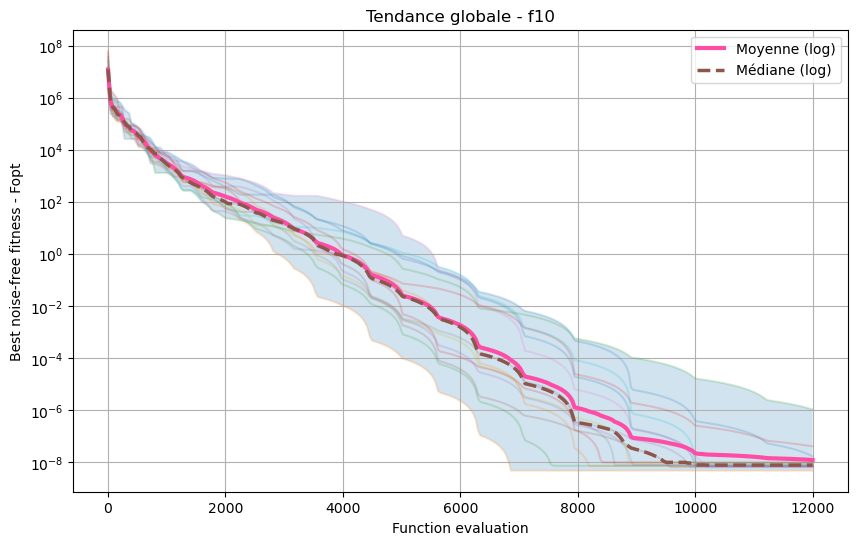

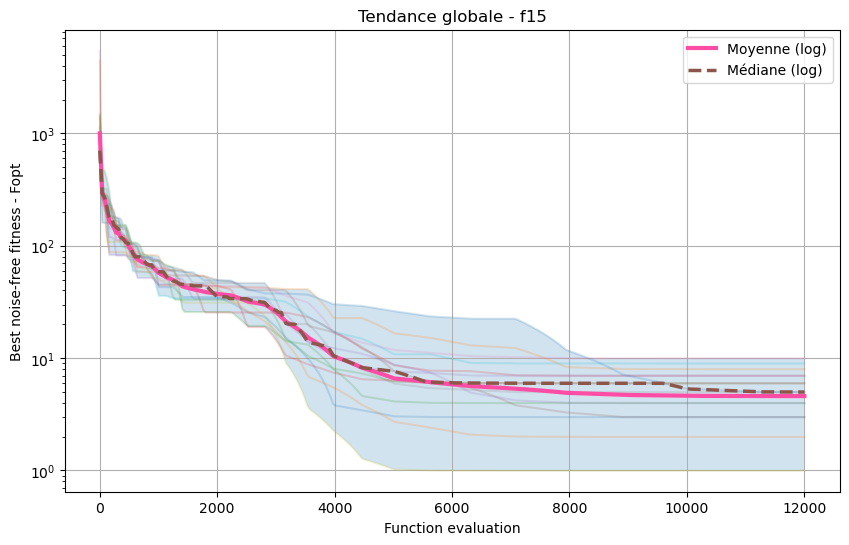

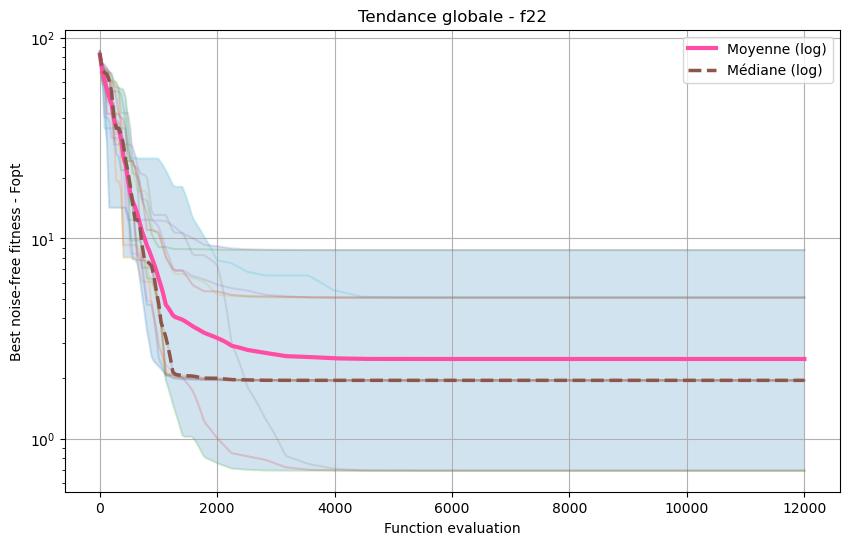

In [1]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    "bbobexp_f2_DIM10.tdat",
    "bbobexp_f7_DIM10.tdat",
    "bbobexp_f10_DIM10.tdat",
    "bbobexp_f15_DIM10.tdat",
    "bbobexp_f22_DIM10.tdat"
]

for file in files:

    with open(file, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            if line:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    x_common = np.linspace(1, 12000, 300)
    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    #  moyenne log
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    #  médiane log (important)
    y_median = np.exp(np.median(np.log(ys), axis=0))

    # min / max
    y_min = np.min(ys, axis=0)
    y_max = np.max(ys, axis=0)

    # --- plot ---
    plt.figure(figsize=(10,6))

    # runs transparents
    for y in ys:
        plt.plot(x_common, y, alpha=0.2)

    # bande
    plt.fill_between(x_common, y_min, y_max, alpha=0.2)

    # moyenne
    plt.plot(x_common, y_mean, color="#ff4da6", linewidth=3, label="Moyenne (log)")

    # médiane
    plt.plot(x_common, y_median, linestyle="--", linewidth=2.5, label="Médiane (log)")

    plt.yscale("log")

    plt.xlabel("Function evaluation")
    plt.ylabel("Best noise-free fitness - Fopt")

    problem = file.split("_")[1]
    plt.title(f"Tendance globale - {problem}")

    plt.legend()
    plt.grid()
    plt.show()

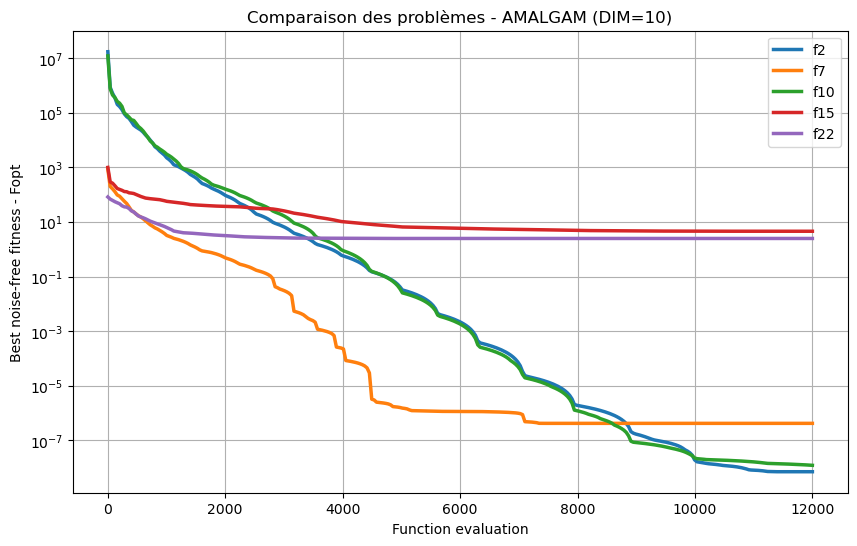

  problem  n_runs    final_mean  final_median    final_best   final_worst
0      f2      15  7.391823e-09  8.170957e-09  4.314771e-09  9.478057e-09
1      f7      15  5.405983e-09  5.968939e-09  8.657111e-10  9.443795e-09
2     f10      15  7.822466e-09  7.839901e-09  4.762995e-09  9.994750e-09
3     f15      15  6.955427e-09  7.397830e-09  3.508546e-09  8.852226e-09
4     f22      15  4.705302e-01  6.918569e-01  2.317371e-09  6.918569e-01
Fichier sauvegardé : resume_problemes_DIM10.csv


In [46]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    "bbobexp_f2_DIM10.tdat",
    "bbobexp_f7_DIM10.tdat",
    "bbobexp_f10_DIM10.tdat",
    "bbobexp_f15_DIM10.tdat",
    "bbobexp_f22_DIM10.tdat"
]

plt.figure(figsize=(10,6))

for file in files:

    with open(file, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            if line:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    x_common = np.linspace(1, 12000, 300)

    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    #  tendance (moyenne en log)
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    # nom du problème
    problem = file.split("_")[1]

    # tracer
    plt.plot(x_common, y_mean, linewidth=2.5, label=problem)

# échelle log obligatoire
plt.yscale("log")

plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Comparaison des problèmes - AMALGAM (DIM=10)")

plt.legend()
plt.grid()
plt.show()

# Sauver un petit tableau récapitulatif
# =========================
summary = []

for problem, res in results.items():
    final_values = res["all_interp"][:, -1]  # dernière valeur interpolée

    summary.append({
        "problem": problem,
        "n_runs": len(res["runs"]),
        "final_mean": np.mean(final_values),
        "final_median": np.median(final_values),
        "final_best": np.min(final_values),
        "final_worst": np.max(final_values)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

summary_df.to_csv("resume_problemes_DIM10.csv", index=False)
print("Fichier sauvegardé : resume_problemes_DIM10.csv")

RANDOMSEARCH - f2 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f2\bbobexp_f2_DIM10_i1.tdat
RS-3 - f2 -> RS-3_bbob_Brockhoff_Hansen\data_f2\bbobexp_f2_DIM10_i1.tdat
BIRMIN - f2 -> BIRMIN\data_f2\bbobexp_f2_DIM10_i1.tdat


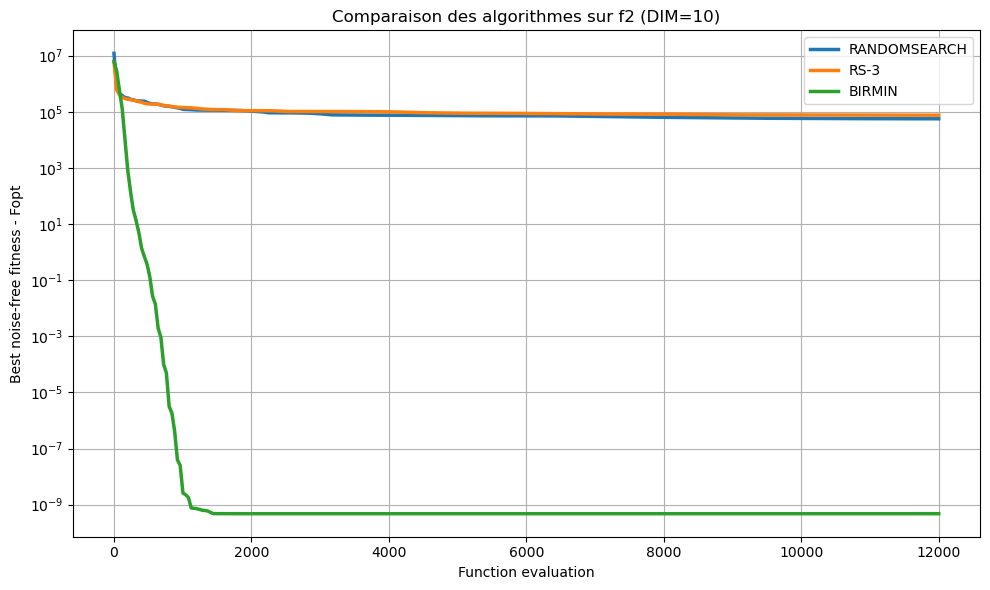

RANDOMSEARCH - f7 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f7\bbobexp_f7_DIM10_i1.tdat
RS-3 - f7 -> RS-3_bbob_Brockhoff_Hansen\data_f7\bbobexp_f7_DIM10_i1.tdat
BIRMIN - f7 -> BIRMIN\data_f7\bbobexp_f7_DIM10_i1.tdat


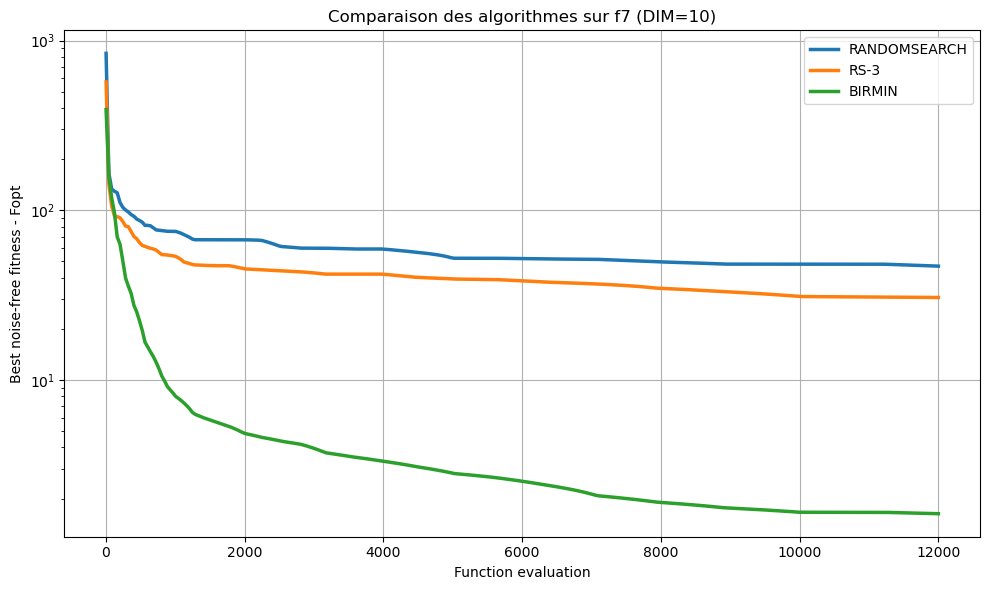

RANDOMSEARCH - f10 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f10\bbobexp_f10_DIM10_i1.tdat
RS-3 - f10 -> RS-3_bbob_Brockhoff_Hansen\data_f10\bbobexp_f10_DIM10_i1.tdat
BIRMIN - f10 -> BIRMIN\data_f10\bbobexp_f10_DIM10_i1.tdat


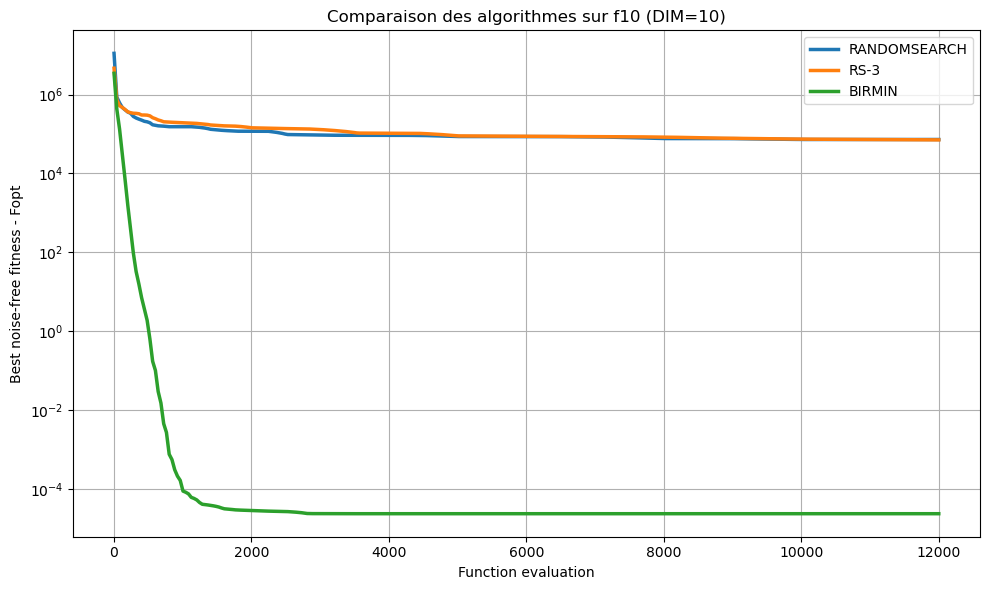

RANDOMSEARCH - f15 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f15\bbobexp_f15_DIM10_i1.tdat
RS-3 - f15 -> RS-3_bbob_Brockhoff_Hansen\data_f15\bbobexp_f15_DIM10_i1.tdat
BIRMIN - f15 -> BIRMIN\data_f15\bbobexp_f15_DIM10_i1.tdat


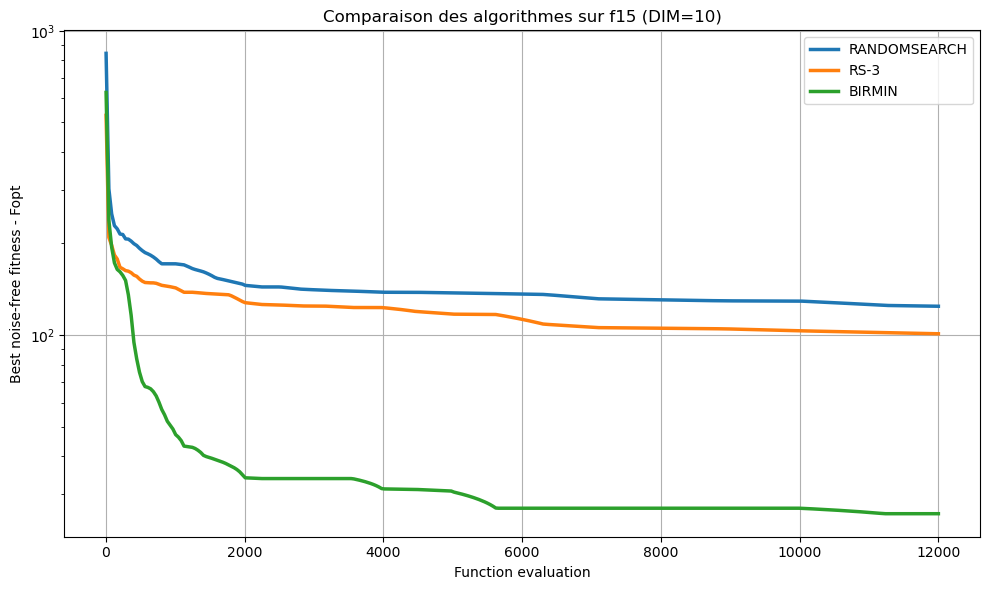

RANDOMSEARCH - f22 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f22\bbobexp_f22_DIM10_i1.tdat
RS-3 - f22 -> RS-3_bbob_Brockhoff_Hansen\data_f22\bbobexp_f22_DIM10_i1.tdat
BIRMIN - f22 -> BIRMIN\data_f22\bbobexp_f22_DIM10_i1.tdat


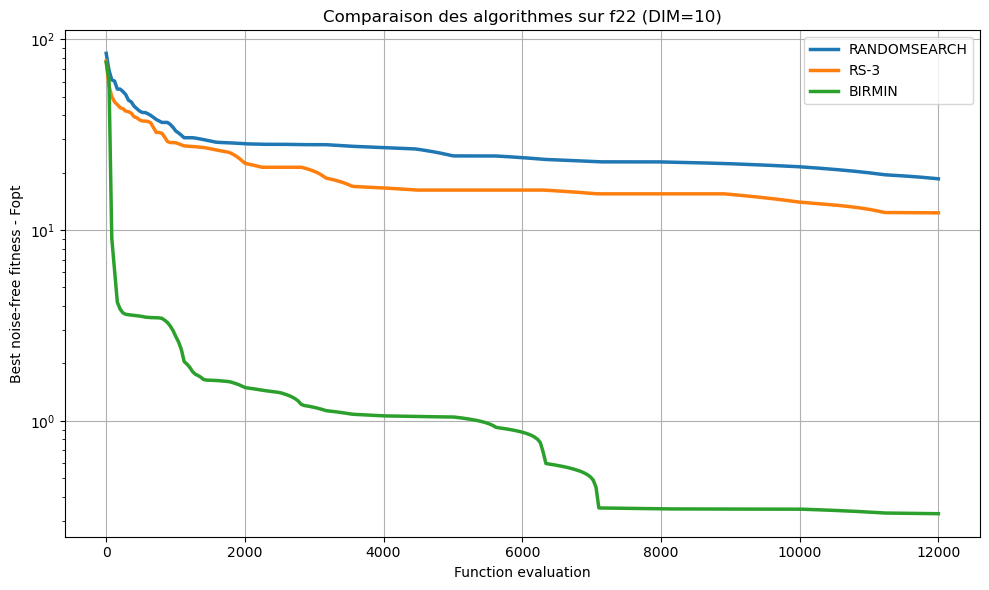

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# Dossiers racine des algorithmes
algorithms = {
    "RANDOMSEARCH": "RANDOMSEARCH-5-1e7D-Brockhoff",
    "RS-3": "RS-3_bbob_Brockhoff_Hansen",
    "BIRMIN": "BIRMIN"
}

# Problèmes étudiés
problems = ["f2", "f7", "f10", "f15", "f22"]

def find_dim10_tdat(base_folder, problem):
    
    folder = os.path.join(base_folder, f"data_{problem}")
    pattern = os.path.join(folder, f"bbobexp_{problem}_DIM10*.tdat")
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"Aucun fichier trouvé pour {problem} dans {folder}")
    
    # On prend le premier trouvé
    return matches[0]

def compute_trend(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    x_common = np.linspace(1, 12000, 300)
    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        # tri par x
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        # interpolation
        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    # moyenne logarithmique
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    return x_common, y_mean

# =========================
# Comparaison des tendances
# =========================
for problem in problems:
    plt.figure(figsize=(10, 6))

    for algo, folder in algorithms.items():
        try:
            file_path = find_dim10_tdat(folder, problem)
            print(f"{algo} - {problem} -> {file_path}")

            x, y = compute_trend(file_path)
            plt.plot(x, y, linewidth=2.5, label=algo)

        except Exception as e:
            print(f"Erreur pour {algo}, {problem} : {e}")

    plt.yscale("log")
    plt.xlabel("Function evaluation")
    plt.ylabel("Best noise-free fitness - Fopt")
    plt.title(f"Comparaison des algorithmes sur {problem} (DIM=10)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

RANDOMSEARCH -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f15\bbobexp_f15_DIM20_i1.tdat
RS-3 -> RS-3_bbob_Brockhoff_Hansen\data_f15\bbobexp_f15_DIM20_i1.tdat
BIRMIN -> BIRMIN\data_f15\bbobexp_f15_DIM20_i1.tdat


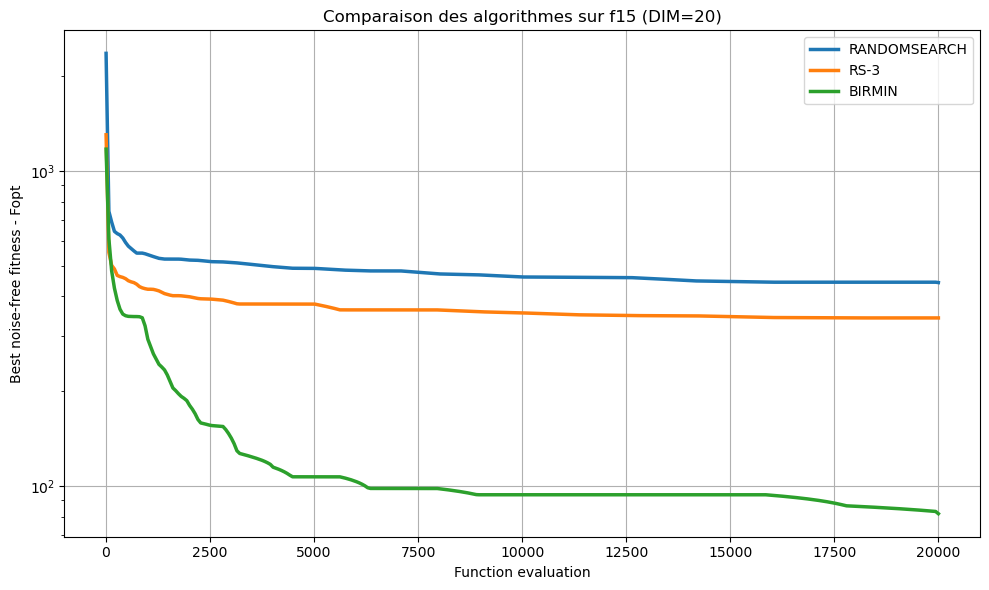

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# Dossiers des algorithmes
algorithms = {
    "RANDOMSEARCH": "RANDOMSEARCH-5-1e7D-Brockhoff",
    "RS-3": "RS-3_bbob_Brockhoff_Hansen",
    "BIRMIN": "BIRMIN"
}

problem = "f15"
dimension = "DIM20"

def find_tdat(base_folder, problem, dimension):
    folder = os.path.join(base_folder, f"data_{problem}")
    pattern = os.path.join(folder, f"bbobexp_{problem}_{dimension}*.tdat")
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder} pour {problem} {dimension}")

    return matches[0]

def compute_trend(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    runs = []
    current_run = []

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.startswith("%"):
            if current_run:
                runs.append(current_run)
                current_run = []
        else:
            current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    # budget commun
    x_common = np.linspace(1, 20000, 300)

    ys = []

    for run in runs:
        x = np.array([float(row[0]) for row in run])
        y = np.array([float(row[2]) for row in run])

        order = np.argsort(x)
        x = x[order]
        y = y[order]

        y_interp = np.interp(x_common, x, y)
        y_interp[y_interp <= 0] = 1e-12

        ys.append(y_interp)

    ys = np.array(ys)

    # moyenne logarithmique
    y_mean = np.exp(np.mean(np.log(ys), axis=0))

    return x_common, y_mean

# =========================
# Comparaison f10 DIM20
# =========================
plt.figure(figsize=(10, 6))

for algo, folder in algorithms.items():
    try:
        file_path = find_tdat(folder, problem, dimension)
        print(f"{algo} -> {file_path}")

        x, y = compute_trend(file_path)
        plt.plot(x, y, linewidth=2.5, label=algo)

    except Exception as e:
        print(f"Erreur pour {algo} : {e}")

plt.yscale("log")
plt.xlabel("Function evaluation")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Comparaison des algorithmes sur f15 (DIM=20)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

RANDOMSEARCH-5 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f10\bbobexp_f10_DIM10_i1.tdat


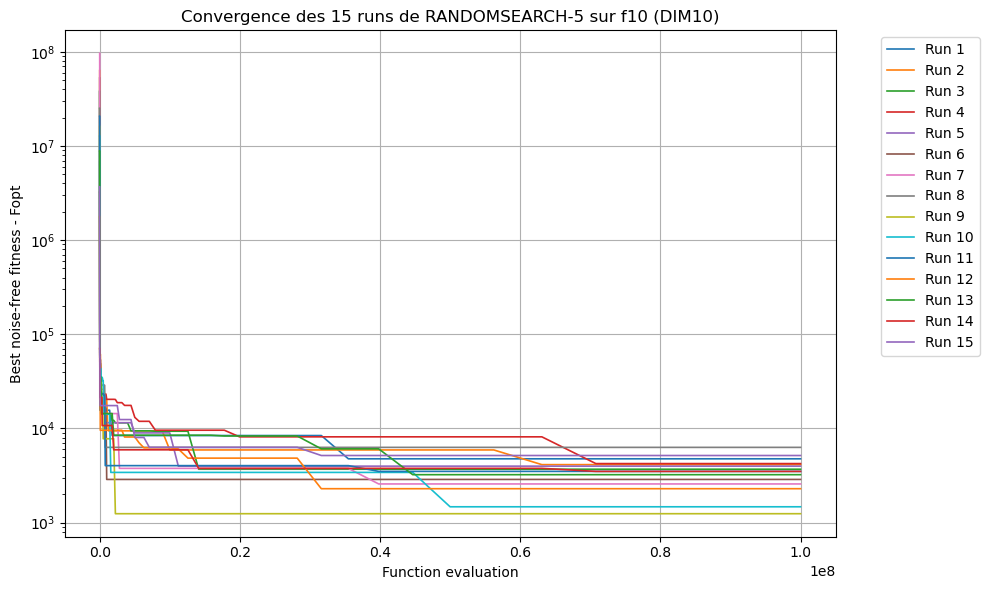

RS-3 -> RS-3_bbob_Brockhoff_Hansen\data_f10\bbobexp_f10_DIM10_i1.tdat


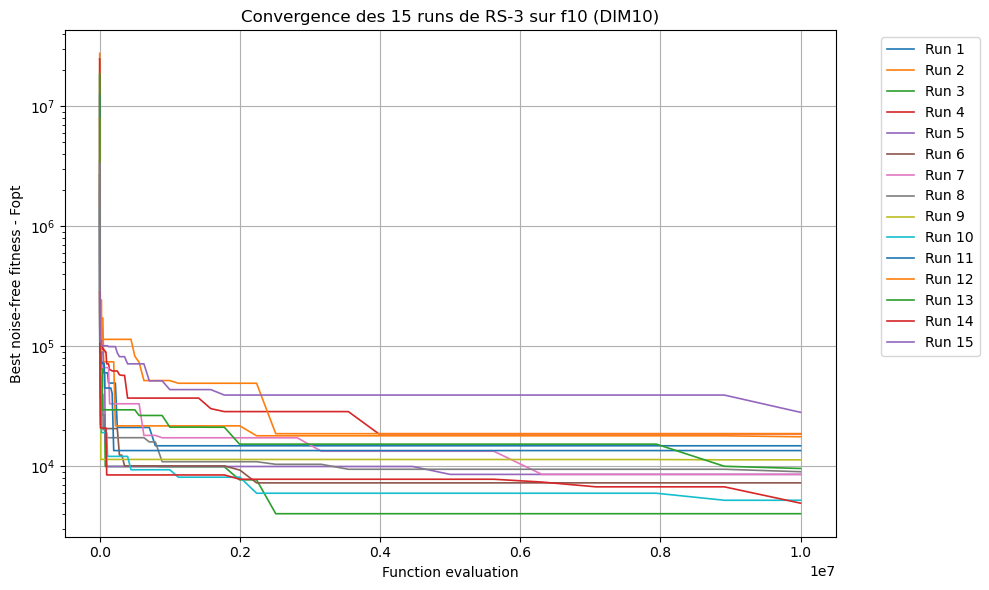

BIRMIN -> BIRMIN\data_f10\bbobexp_f10_DIM10_i1.tdat


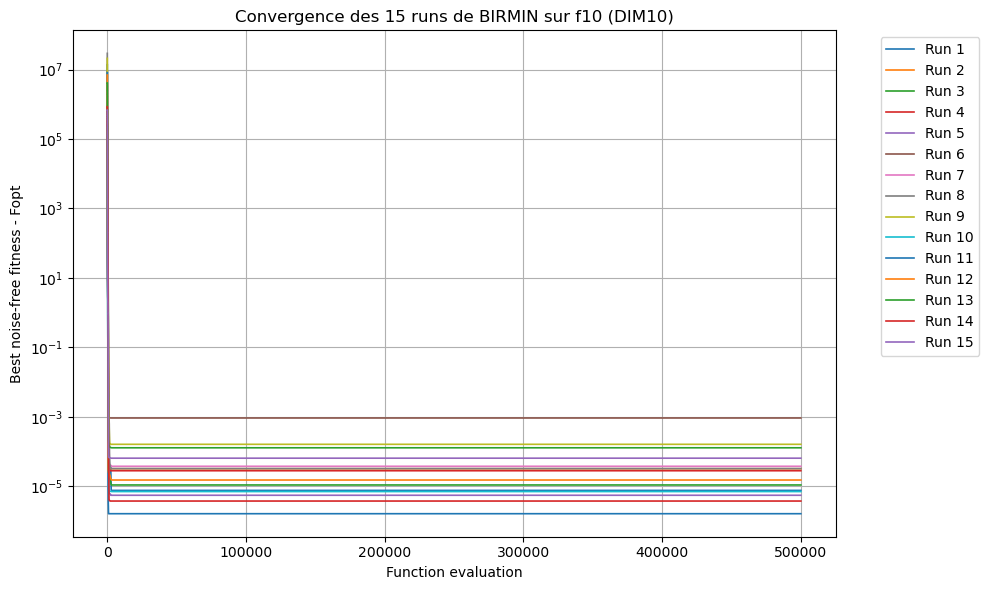

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# Dossiers des algorithmes
algorithms = {
    "RANDOMSEARCH-5": "RANDOMSEARCH-5-1e7D-Brockhoff",
    "RS-3": "RS-3_bbob_Brockhoff_Hansen",
    "BIRMIN": "BIRMIN"
}

problem = "f10"
dimension = "DIM10"

def find_tdat(base_folder, problem, dimension):
    folder = os.path.join(base_folder, f"data_{problem}")
    pattern = os.path.join(folder, f"bbobexp_{problem}_{dimension}*.tdat")
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder} pour {problem} {dimension}")

    return matches[0]

def read_runs(file_path):
    runs = []
    current_run = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith("%"):
                if current_run:
                    runs.append(current_run)
                    current_run = []
            else:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    return runs

# =========================
# Un graphe par algorithme
# =========================
for algo, folder in algorithms.items():
    try:
        file_path = find_tdat(folder, problem, dimension)
        print(f"{algo} -> {file_path}")

        runs = read_runs(file_path)

        plt.figure(figsize=(10, 6))

        for i, run in enumerate(runs):
            x = np.array([float(row[0]) for row in run])
            y = np.array([float(row[2]) for row in run])

            mask = y > 0
            x = x[mask]
            y = y[mask]

            if len(x) > 1:
                plt.plot(x, y, linewidth=1.2, label=f"Run {i+1}")

        plt.yscale("log")
        plt.xlabel("Function evaluation")
        plt.ylabel("Best noise-free fitness - Fopt")
        plt.title(f"Convergence des 15 runs de {algo} sur {problem} ({dimension})")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.grid()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erreur pour {algo} : {e}")

RANDOMSEARCH-5 -> RANDOMSEARCH-5-1e7D-Brockhoff\data_f10\bbobexp_f10_DIM10_i1.tdat


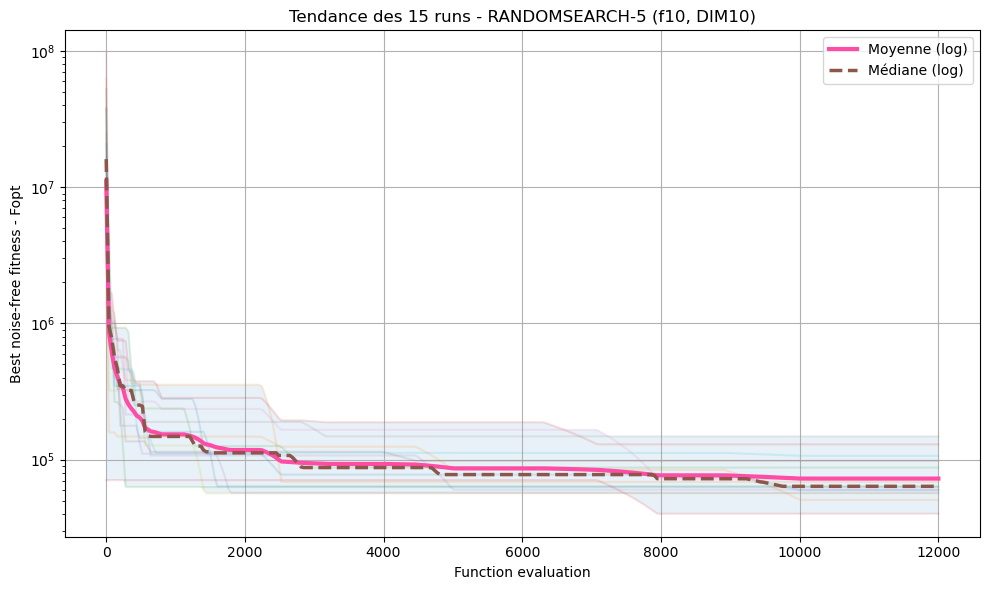

RS-3 -> RS-3_bbob_Brockhoff_Hansen\data_f10\bbobexp_f10_DIM10_i1.tdat


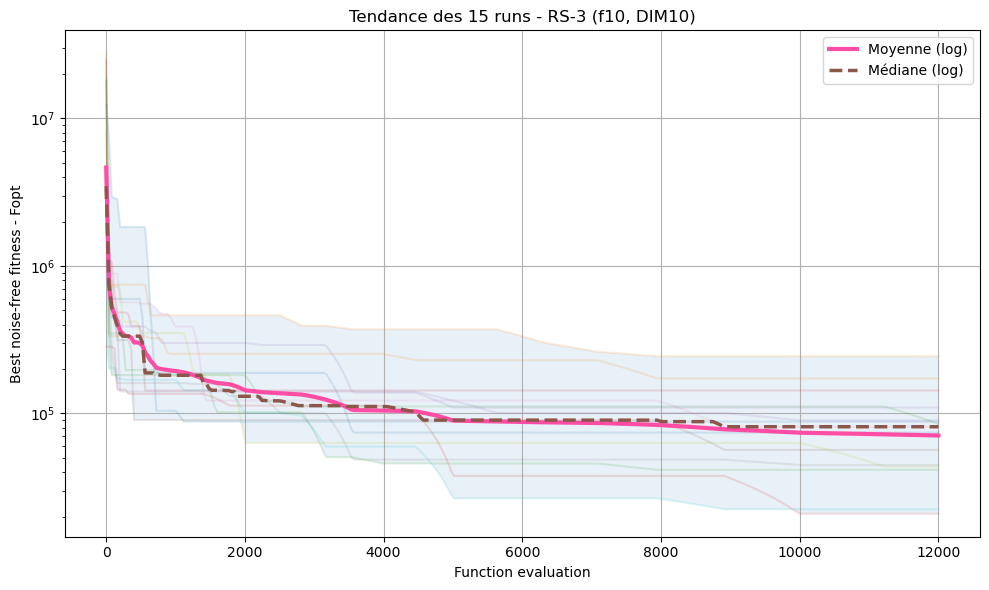

BIRMIN -> BIRMIN\data_f10\bbobexp_f10_DIM10_i1.tdat


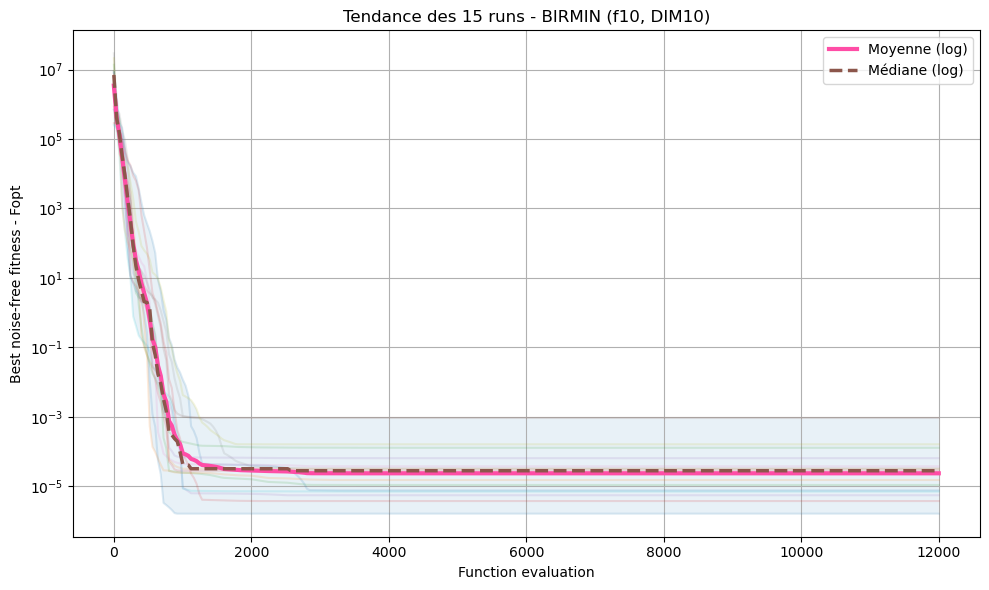

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

algorithms = {
    "RANDOMSEARCH-5": "RANDOMSEARCH-5-1e7D-Brockhoff",
    "RS-3": "RS-3_bbob_Brockhoff_Hansen",
    "BIRMIN": "BIRMIN"
}

problem = "f10"
dimension = "DIM10"

def find_tdat(base_folder, problem, dimension):
    folder = os.path.join(base_folder, f"data_{problem}")
    pattern = os.path.join(folder, f"bbobexp_{problem}_{dimension}*.tdat")
    matches = glob.glob(pattern)

    if len(matches) == 0:
        raise FileNotFoundError(f"Aucun fichier trouvé dans {folder}")

    return matches[0]

def read_runs(file_path):
    runs = []
    current_run = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith("%"):
                if current_run:
                    runs.append(current_run)
                    current_run = []
            else:
                current_run.append(line.split())

    if current_run:
        runs.append(current_run)

    return runs

# =========================
# 1 figure par algo
# =========================
for algo, folder in algorithms.items():
    try:
        file_path = find_tdat(folder, problem, dimension)
        print(f"{algo} -> {file_path}")

        runs = read_runs(file_path)

        x_common = np.linspace(1, 12000, 300)
        ys = []

        for run in runs:
            x = np.array([float(row[0]) for row in run])
            y = np.array([float(row[2]) for row in run])

            order = np.argsort(x)
            x = x[order]
            y = y[order]

            y_interp = np.interp(x_common, x, y)
            y_interp[y_interp <= 0] = 1e-12

            ys.append(y_interp)

        ys = np.array(ys)

        # moyenne log
        y_mean = np.exp(np.mean(np.log(ys), axis=0))

        # médiane log
        y_median = np.exp(np.median(np.log(ys), axis=0))

        # min / max (optionnel pour shading)
        y_min = np.min(ys, axis=0)
        y_max = np.max(ys, axis=0)

        # =========================
        # PLOT
        # =========================
        plt.figure(figsize=(10, 6))

        # runs (léger)
        for y in ys:
            plt.plot(x_common, y, alpha=0.15)

        # bande min/max
        plt.fill_between(x_common, y_min, y_max, alpha=0.1)

        # moyenne
        plt.plot(x_common, y_mean, color="#ff4da6", linewidth=3, label="Moyenne (log)")

        # médiane
        plt.plot(x_common, y_median, linestyle="--", linewidth=2.5, label="Médiane (log)")

        plt.yscale("log")

        plt.xlabel("Function evaluation")
        plt.ylabel("Best noise-free fitness - Fopt")
        plt.title(f"Tendance des 15 runs - {algo} ({problem}, {dimension})")

        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erreur pour {algo} : {e}")